In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# Set the random seed for reproducibility
np.random.seed(42)

# Set a nice figure size for our plots
plt.rcParams["figure.figsize"] = [10, 6]

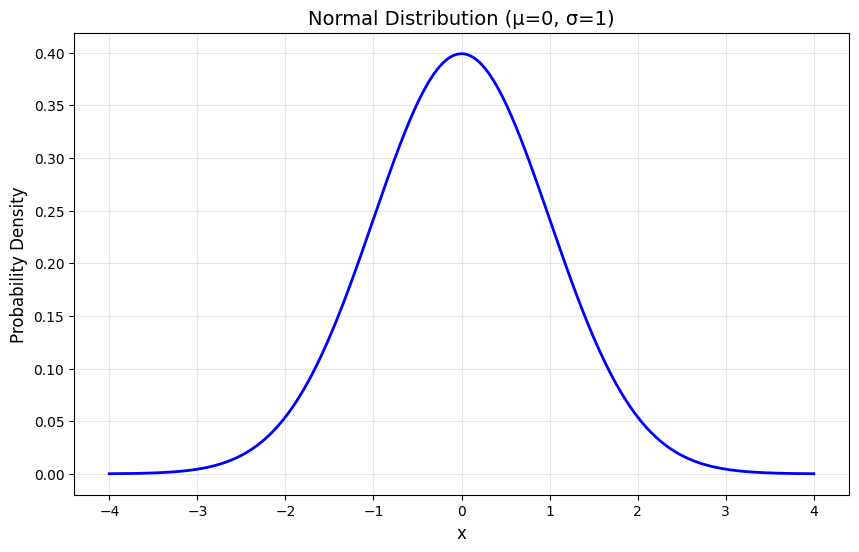

In [2]:
# Define the parameters for our normal distribution
mu = 0  # mean
sigma = 1  # standard deviation

# Generate x values
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)

# Calculate the probability density function (PDF)
# Your task: Use stats.norm.pdf to calculate the PDF values
y = stats.norm.pdf(x, mu, sigma)

# Create the plot
plt.plot(x, y, "b-", linewidth=2)
plt.title("Normal Distribution (μ=0, σ=1)", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

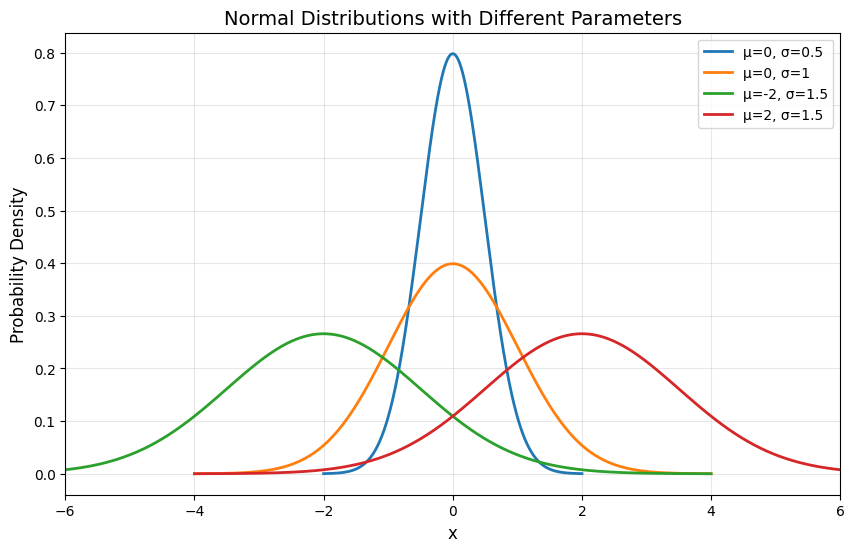

In [3]:
# Define different parameters
mu_values = [0, 0, -2, 2]
sigma_values = [0.5, 1, 1.5, 1.5]

# Create the plot
plt.figure(figsize=(10, 6))

# Your task: Loop through the parameters (pairwise) and plot each distribution
for mu, sigma in zip(mu_values, sigma_values):
    # Calculate the PDF values
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
    y = stats.norm.pdf(x, mu, sigma)

    # Plot the distribution
    plt.plot(x, y, linewidth=2, label=f"μ={mu}, σ={sigma}")

plt.title("Normal Distributions with Different Parameters", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-6, 6)
plt.show()

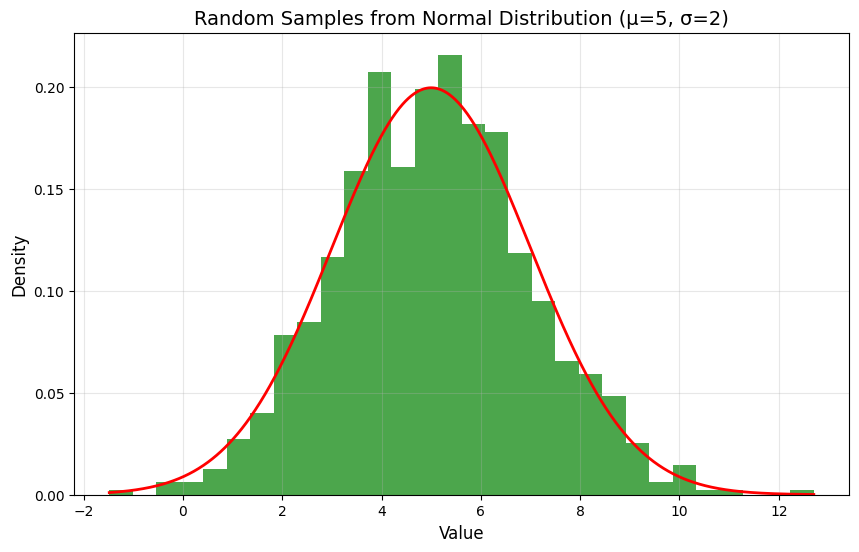

Sample mean: 5.0387 (Expected: 5)
Sample standard deviation: 1.9575 (Expected: 2)


In [4]:
# Your task: Generate 1000 random samples from a normal distribution with mean=5 and std=2
samples = np.random.normal(5, 2, 1000)

# Create a histogram of the samples
plt.hist(samples, bins=30, density=True, alpha=0.7, color="green")

# Overlay the theoretical PDF
x = np.linspace(min(samples), max(samples), 1000)
pdf = stats.norm.pdf(x, 5, 2)
plt.plot(x, pdf, "r-", linewidth=2)

plt.title("Random Samples from Normal Distribution (μ=5, σ=2)", fontsize=14)
plt.xlabel("Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Calculate the sample mean and standard deviation
sample_mean = np.mean(samples)
sample_std = np.std(samples)

print(f"Sample mean: {sample_mean:.4f} (Expected: 5)")
print(f"Sample standard deviation: {sample_std:.4f} (Expected: 2)")

In [5]:
# Define our normal distribution
mu, sigma = 0, 1

# Your task: Calculate the probability within 1, 2, and 3 standard deviations
# Hint: Use stats.norm.cdf() to find the cumulative probability

# Within 1 sigma
prob_1sigma = stats.norm.cdf(mu + sigma, mu, sigma) - stats.norm.cdf(
    mu - sigma, mu, sigma
)
prob_2sigma = stats.norm.cdf(mu + 2 * sigma, mu, sigma) - stats.norm.cdf(
    mu - 2 * sigma, mu, sigma
)
prob_3sigma = stats.norm.cdf(mu + 3 * sigma, mu, sigma) - stats.norm.cdf(
    mu - 3 * sigma, mu, sigma
)

# Print the results
print(f"Probability within 1σ: {prob_1sigma:.4f} (Expected: ~0.6827)")
print(f"Probability within 2σ: {prob_2sigma:.4f} (Expected: ~0.9545)")
print(f"Probability within 3σ: {prob_3sigma:.4f} (Expected: ~0.9973)")

Probability within 1σ: 0.6827 (Expected: ~0.6827)
Probability within 2σ: 0.9545 (Expected: ~0.9545)
Probability within 3σ: 0.9973 (Expected: ~0.9973)


Mean of z-scores: 0.000000
Standard deviation of z-scores: 1.000000


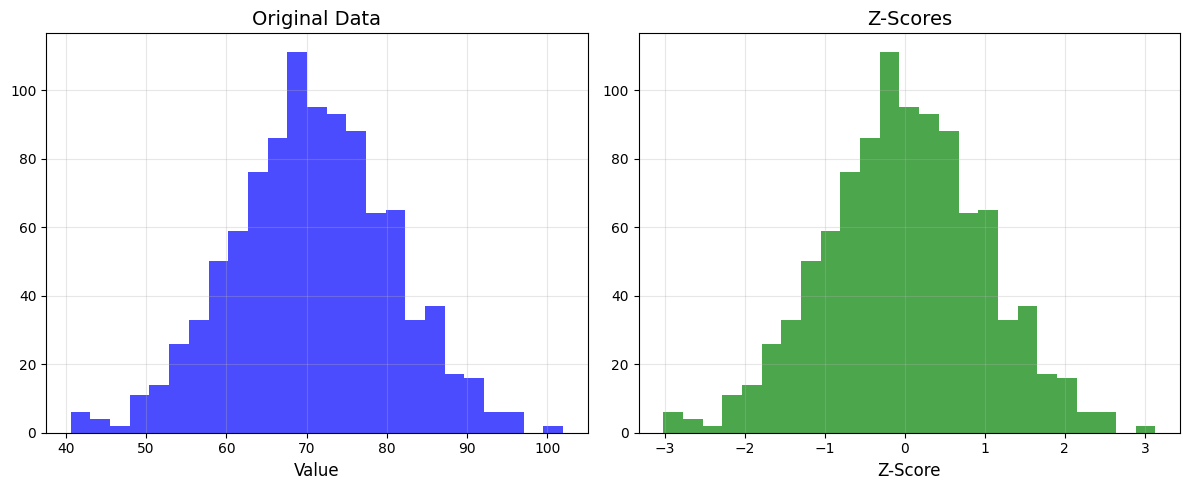

In [6]:
# Create some data with mean=70 and std=10
data = np.random.normal(70, 10, 1000)

# Your task: Calculate the z-scores for this data
z_scores = (data - np.mean(data)) / np.std(data)

# Verify that z-scores have mean ≈ 0 and std ≈ 1
print(f"Mean of z-scores: {np.mean(z_scores):.6f}")
print(f"Standard deviation of z-scores: {np.std(z_scores):.6f}")

# Plot the original data and the z-scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(data, bins=25, alpha=0.7, color="blue")
ax1.set_title("Original Data", fontsize=14)
ax1.set_xlabel("Value", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.hist(z_scores, bins=25, alpha=0.7, color="green")
ax2.set_title("Z-Scores", fontsize=14)
ax2.set_xlabel("Z-Score", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

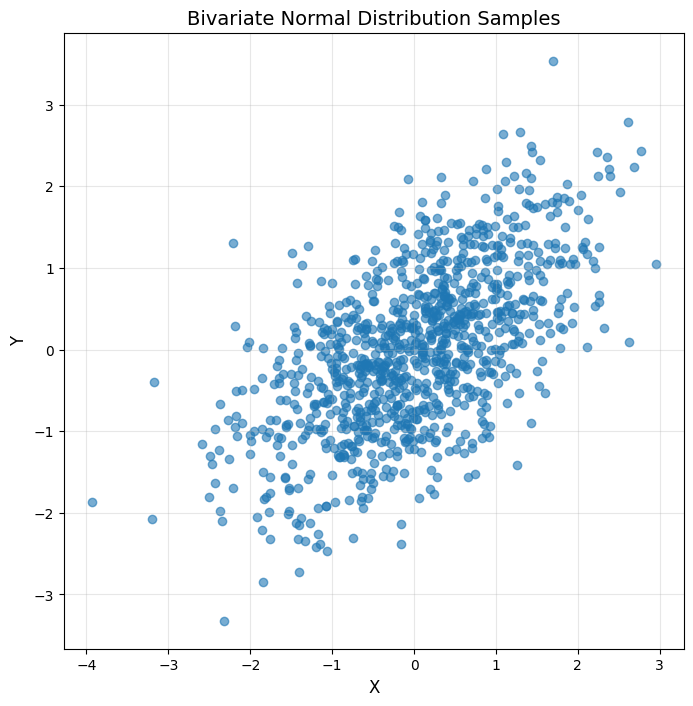

Sample correlation: 0.6036 (Expected: ~0.6)


In [7]:
# Define parameters
mean = [0, 0]  # means of the two variables
cov = [
    [1, 0.6],
    [0.6, 1],
]  # covariance matrix (diagonal is variances, off-diagonal is covariance)

# Your task: Generate 1000 samples from this bivariate normal distribution
# Hint: Use np.random.multivariate_normal
samples = np.random.multivariate_normal(mean, cov, 1000)

# Extract x and y components
x = samples[:, 0]
y = samples[:, 1]

# Create a scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(x, y, alpha=0.6)
plt.title("Bivariate Normal Distribution Samples", fontsize=14)
plt.xlabel("X", fontsize=12)
plt.ylabel("Y", fontsize=12)
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()

# Check the correlation between x and y
correlation = np.corrcoef(x, y)[0, 1]
print(f"Sample correlation: {correlation:.4f} (Expected: ~0.6)")

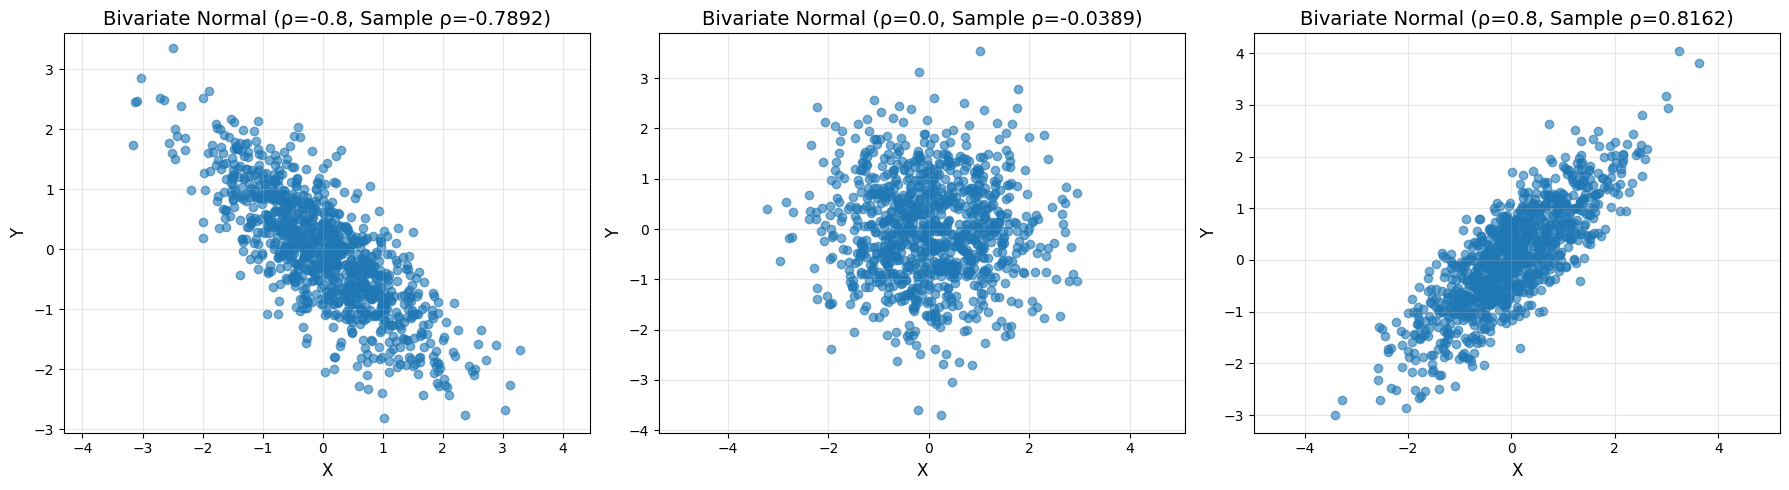

In [8]:
# Create a function to generate and plot bivariate normal data
def plot_bivariate_normal(correlation, n_samples=1000):
    """Generate and plot a bivariate normal distribution with given correlation."""
    # Create the covariance matrix
    cov = [[1, correlation], [correlation, 1]]

    # Your task: Generate the samples
    samples = np.random.multivariate_normal([0, 0], cov, n_samples)

    x, y = samples[:, 0], samples[:, 1]

    # Calculate the sample correlation
    sample_corr = np.corrcoef(x, y)[0, 1]

    # Create the plot
    plt.scatter(x, y, alpha=0.6)
    plt.title(
        f"Bivariate Normal (ρ={correlation:.1f}, Sample ρ={sample_corr:.4f})",
        fontsize=14,
    )
    plt.xlabel("X", fontsize=12)
    plt.ylabel("Y", fontsize=12)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)


# Create a figure with multiple plots for different correlations
plt.figure(figsize=(18, 5))

# Your task: Create subplots for correlations of -0.8, 0, and 0.8
correlations = [-0.8, 0, 0.8]

for i, corr in enumerate(correlations):
    plt.subplot(1, 3, i + 1)
    plot_bivariate_normal(corr)

plt.tight_layout()
plt.show()